### Data Analysis

In [1]:
from src.data_prep import CreditDataAnalyzer

In [2]:
# 1. Initialisation
analyzer = CreditDataAnalyzer()

In [3]:
# 2. Load data
df = analyzer.load_data()

✅ CSV dataset already exists locally.


In [4]:
# 3. Exploration and cleaning
analyzer.explore_basics()
analyzer.clean_data()


--- Basic Exploration ---
Dataset shape: (30000, 25)

Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



--- Data Cleaning ---
Number of duplicate rows: 0
✅ Data cleaned (ID removed, target renamed to 'IsDefault').



Target distribution (%) :
 IsDefault
0    77.88
1    22.12
Name: proportion, dtype: float64


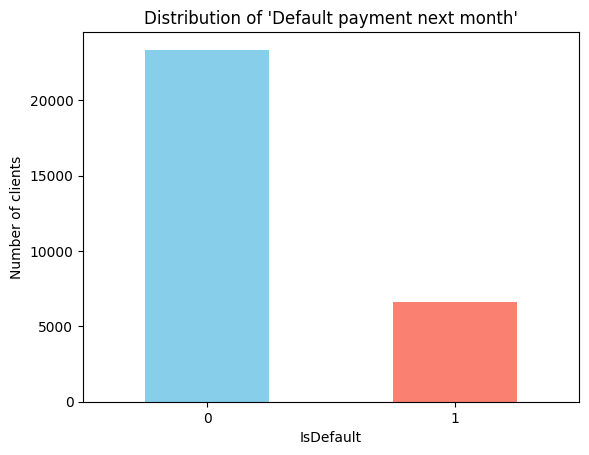


--- Bias check for feature 'SEX' ---
IsDefault         0         1
SEX                          
1          0.758328  0.241672
2          0.792237  0.207763


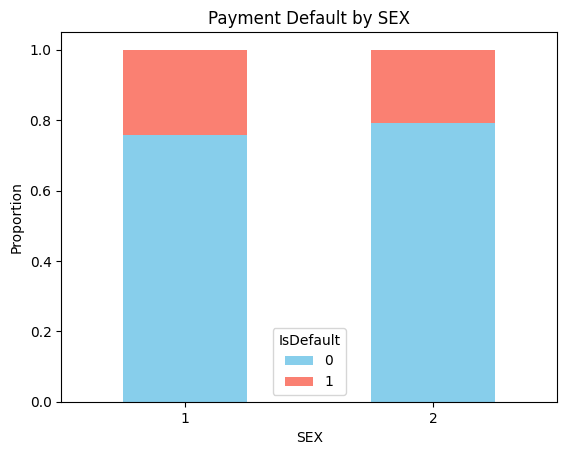


--- Bias check for feature 'EDUCATION' ---
IsDefault         0         1
EDUCATION                    
0          1.000000  0.000000
1          0.807652  0.192348
2          0.762651  0.237349
3          0.748424  0.251576
4          0.943089  0.056911
5          0.935714  0.064286
6          0.843137  0.156863


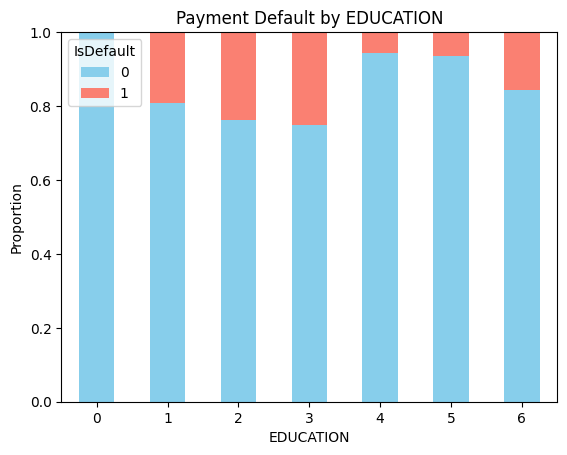


--- Bias check for feature 'MARRIAGE' ---
IsDefault         0         1
MARRIAGE                     
0          0.907407  0.092593
1          0.765283  0.234717
2          0.790717  0.209283
3          0.739938  0.260062


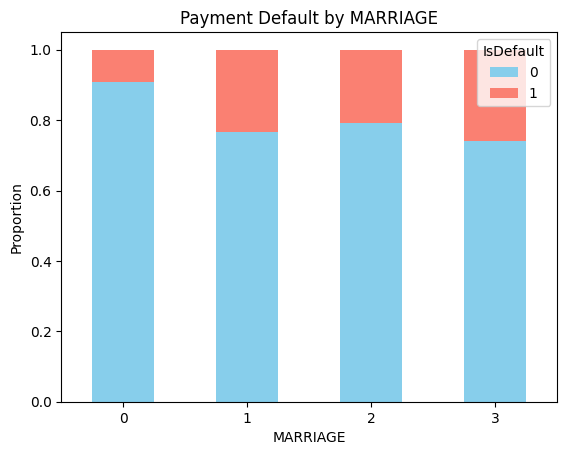


--- Bias check for feature 'AGE' ---
IsDefault         0         1
AGE                          
21         0.791045  0.208955
22         0.698214  0.301786
23         0.734694  0.265306
24         0.733807  0.266193
25         0.745363  0.254637
26         0.798567  0.201433
27         0.788084  0.211916
28         0.797019  0.202981
29         0.804984  0.195016
30         0.803584  0.196416
31         0.811832  0.188168
32         0.805699  0.194301
33         0.812391  0.187609
34         0.801205  0.198795
35         0.796945  0.203055
36         0.770758  0.229242
37         0.780019  0.219981
38         0.794492  0.205508
39         0.791405  0.208595
40         0.785057  0.214943
41         0.775485  0.224515
42         0.767003  0.232997
43         0.776119  0.223881
44         0.768571  0.231429
45         0.811994  0.188006
46         0.724561  0.275439
47         0.760479  0.239521
48         0.776824  0.223176
49         0.736726  0.263274
50         0.754258  0.245742
51

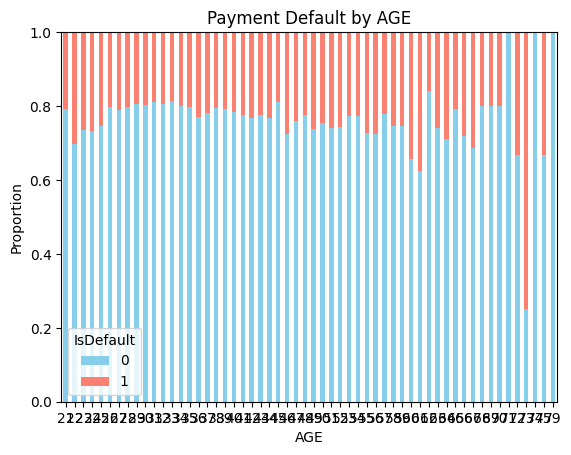

In [5]:
# 4. Visualisations (EDA)
analyzer.plot_target_distribution()
analyzer.check_bias(feature='SEX')
analyzer.check_bias(feature='EDUCATION')
analyzer.check_bias(feature='MARRIAGE')
analyzer.check_bias(feature='AGE')


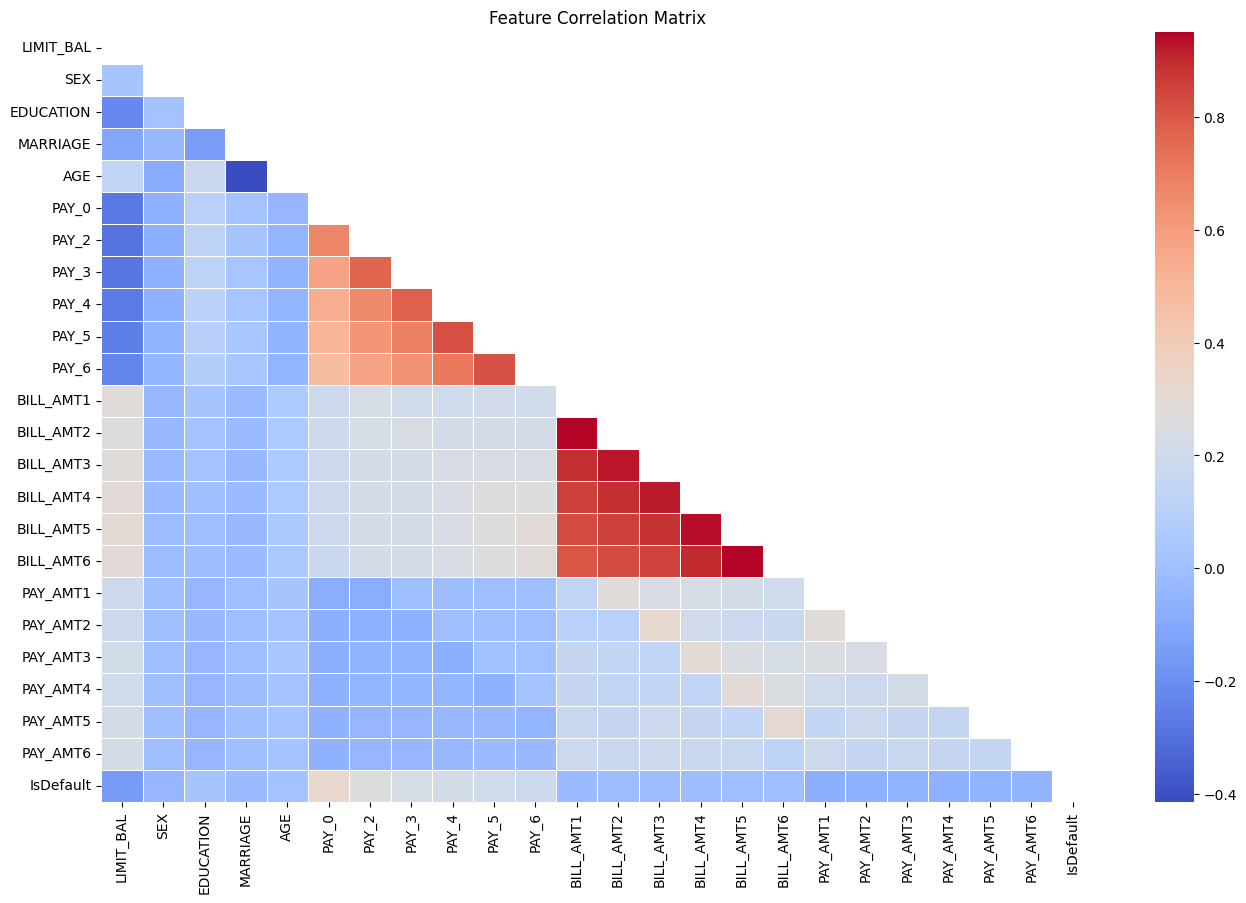

In [6]:
analyzer.plot_correlation_matrix() 

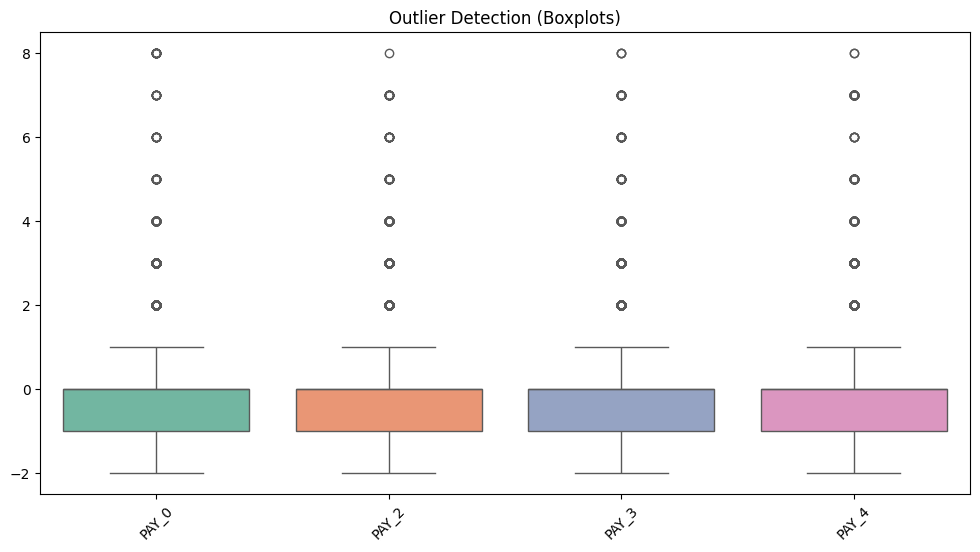

In [7]:
# Exemple d'utilisation de la fonction bonus d'outliers sur quelques features d'historique de paiement
analyzer.plot_feature_boxplot(features=['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']) 


In [8]:
# 5. Préparation Machine Learning
X_train, X_test, y_train, y_test = analyzer.prepare_for_modeling()
weights = analyzer.compute_model_weights()


--- Machine Learning Preparation ---
✅ Data split and standardized successfully!
Training set size: (24000, 23)
Test set size: (6000, 23)

--- Recommended weights to handle class imbalance ---
Class 0 -> 0.64
Class 1 -> 2.26


In [9]:
# 1. Charge l'extension magique qui permet le rechargement
%load_ext autoreload

# 2. Demande à Jupyter de recharger les modules avant chaque exécution de cellule
%autoreload 2

# 3. Ensuite, tu peux faire tes imports tranquillement :
from src.model import train_model, evaluate_model

In [10]:
# 1. Assuming your analyzer is already done preparing the data:
# X_train_scaled, X_test_scaled, y_train, y_test = analyzer.prepare_for_modeling()
# weights = analyzer.compute_model_weights()

# 2. Train the model using the preprocessed data and computed weights
# Note: I bumped epochs to 100 because PyTorch usually needs a bit more time to learn 
# when processing the entire dataset at once (full-batch).

trained_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    class_weights=weights
)

# 3. Evaluate the model on the unseen test set
accuracy = evaluate_model(trained_model, X_test, y_test)


🚀 Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.3
Epoch [20/300], Loss: 0.9135, Current LR: 0.009891
Epoch [40/300], Loss: 0.8911, Current LR: 0.009568
Epoch [60/300], Loss: 0.8783, Current LR: 0.009046
Epoch [80/300], Loss: 0.8711, Current LR: 0.008347
Epoch [100/300], Loss: 0.8666, Current LR: 0.007503
Epoch [120/300], Loss: 0.8582, Current LR: 0.006549
Epoch [140/300], Loss: 0.8569, Current LR: 0.005527
Epoch [160/300], Loss: 0.8525, Current LR: 0.004483
Epoch [180/300], Loss: 0.8520, Current LR: 0.003461
Epoch [200/300], Loss: 0.8501, Current LR: 0.002508
Epoch [220/300], Loss: 0.8494, Current LR: 0.001663
Epoch [240/300], Loss: 0.8494, Current LR: 0.000964
Epoch [260/300], Loss: 0.8456, Current LR: 0.000442
Epoch [280/300], Loss: 0.8478, Current LR: 0.000119
Epoch [300/300], Loss: 0.8445, Current LR: 0.000010

🎯 Accuracy on test set: 74.73%

--- Classification Report ---
              precision    recall  f1-score   support

    

In [11]:
optimized_model = train_model(
    X_train, 
    y_train, 
    epochs=300,       # Keep 300, scheduler & dropout handle it now
    start_lr=0.01,    # High initial LR to learn fast
    class_weights=weights,
    dropout_p=0.4     # 40% dropout to fight overfitting
)

# 3. Final evaluation
print("\n--- RESULTS WITH DROPOUT AND SCHEDULER ---")
evaluate_model(optimized_model, X_test, y_test)


🚀 Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.9215, Current LR: 0.009891
Epoch [40/300], Loss: 0.8997, Current LR: 0.009568
Epoch [60/300], Loss: 0.8845, Current LR: 0.009046
Epoch [80/300], Loss: 0.8798, Current LR: 0.008347
Epoch [100/300], Loss: 0.8759, Current LR: 0.007503
Epoch [120/300], Loss: 0.8686, Current LR: 0.006549
Epoch [140/300], Loss: 0.8664, Current LR: 0.005527
Epoch [160/300], Loss: 0.8609, Current LR: 0.004483
Epoch [180/300], Loss: 0.8634, Current LR: 0.003461
Epoch [200/300], Loss: 0.8647, Current LR: 0.002508
Epoch [220/300], Loss: 0.8573, Current LR: 0.001663
Epoch [240/300], Loss: 0.8572, Current LR: 0.000964
Epoch [260/300], Loss: 0.8570, Current LR: 0.000442
Epoch [280/300], Loss: 0.8612, Current LR: 0.000119
Epoch [300/300], Loss: 0.8577, Current LR: 0.000010

--- RESULTS WITH DROPOUT AND SCHEDULER ---

🎯 Accuracy on test set: 74.88%

--- Classification Report ---
              p

0.7488333333333334

In [12]:
from src.fairness import evaluate_fairness, get_sample_weights, plot_fairness_comparison, get_combined_weights

In [13]:
# 1. Évaluer l'équité du modèle actuel (avant mitigation)
print("--- AUDIT DU MODÈLE STANDARD ---")
mf_before = evaluate_fairness(optimized_model, X_test, y_test)

# 2. Calculer les nouveaux poids d'instances avec Kamiran & Calders
fairness_weights = get_sample_weights(X_train, y_train)

# 3. Ré-entraîner un nouveau modèle avec ces poids correctifs
print("\n--- ENTRAÎNEMENT DU MODÈLE ÉQUITABLE ---")
fair_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    instance_weights=fairness_weights, # On passe les nouveaux poids ici !
    dropout_p=0.4
)

# 4. Évaluer l'équité du nouveau modèle
print("\n--- AUDIT DU NOUVEAU MODÈLE ---")
mf_after = evaluate_fairness(fair_model, X_test, y_test)

# 5. Vérifier que la précision (Accuracy/Recall) n'a pas trop chuté
print("\n--- PERFORMANCES DU NOUVEAU MODÈLE ---")
evaluate_model(fair_model, X_test, y_test)

--- AUDIT DU MODÈLE STANDARD ---

⚖️ Starting Fairness Audit
Prediction rate of 'Default' for Men : 33.89%
Prediction rate of 'Default' for Women : 27.68%
🛑 Demographic Parity Difference: 6.21%
⚠️ ALERT: The model is biased. The gap between genders exceeds 5%.

⚖️ Calculating mitigation weights (Kamiran & Calders)

--- ENTRAÎNEMENT DU MODÈLE ÉQUITABLE ---

🚀 Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.4789, Current LR: 0.009891
Epoch [40/300], Loss: 0.4594, Current LR: 0.009568
Epoch [60/300], Loss: 0.4500, Current LR: 0.009046
Epoch [80/300], Loss: 0.4454, Current LR: 0.008347
Epoch [100/300], Loss: 0.4406, Current LR: 0.007503
Epoch [120/300], Loss: 0.4389, Current LR: 0.006549
Epoch [140/300], Loss: 0.4389, Current LR: 0.005527
Epoch [160/300], Loss: 0.4340, Current LR: 0.004483
Epoch [180/300], Loss: 0.4345, Current LR: 0.003461
Epoch [200/300], Loss: 0.4341, Current LR: 0.002508
Epoch [220/300], Loss: 0

0.8213333333333334


📊 Generating Fairness Comparison Chart...


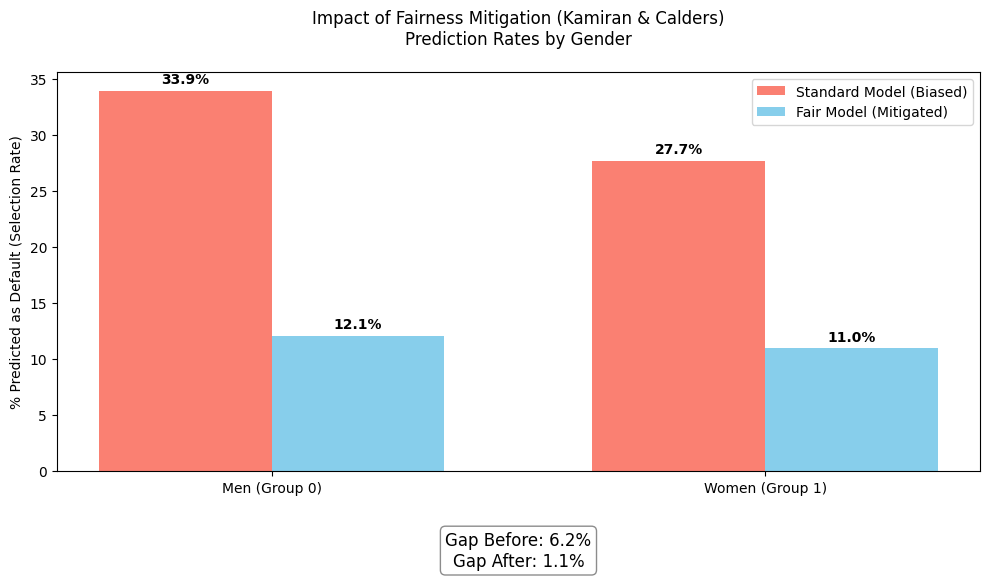

In [14]:
# Generate the visual comparison
plot_fairness_comparison(mf_before, mf_after)

In [15]:
# 1. Récupérer les poids de classe de base (si tu ne les as plus en mémoire)
base_weights = analyzer.compute_model_weights() 

# 2. Calculer les super-poids combinés
combined_weights = get_combined_weights(X_train, y_train, class_weights=base_weights)

# 3. Entraîner le Master Model
print("\n--- ENTRAÎNEMENT DU MASTER MODEL (ÉQUITABLE ET PERFORMANT) ---")
master_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    instance_weights=combined_weights, # On utilise les poids combinés
    dropout_p=0.4
)

# 4. Évaluer l'Équité (Fairness)
print("\n--- AUDIT DU MASTER MODEL ---")
mf_master = evaluate_fairness(master_model, X_test, y_test)

# 5. Évaluer la Performance Métier (Recall/Accuracy)
print("\n--- PERFORMANCES DU MASTER MODEL ---")
evaluate_model(master_model, X_test, y_test)

# 6. (Optionnel) Afficher le graphique de comparaison avec le tout premier modèle
# plot_fairness_comparison(mf_before, mf_master)


--- Recommended weights to handle class imbalance ---
Class 0 -> 0.64
Class 1 -> 2.26

⚖️ Calculating COMBINED weights (Fairness + Class Imbalance) by Olivia...

--- ENTRAÎNEMENT DU MASTER MODEL (ÉQUITABLE ET PERFORMANT) ---

🚀 Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.4757, Current LR: 0.009891
Epoch [40/300], Loss: 0.4555, Current LR: 0.009568
Epoch [60/300], Loss: 0.4478, Current LR: 0.009046
Epoch [80/300], Loss: 0.4444, Current LR: 0.008347
Epoch [100/300], Loss: 0.4419, Current LR: 0.007503
Epoch [120/300], Loss: 0.4401, Current LR: 0.006549
Epoch [140/300], Loss: 0.4369, Current LR: 0.005527
Epoch [160/300], Loss: 0.4378, Current LR: 0.004483
Epoch [180/300], Loss: 0.4363, Current LR: 0.003461
Epoch [200/300], Loss: 0.4342, Current LR: 0.002508
Epoch [220/300], Loss: 0.4357, Current LR: 0.001663
Epoch [240/300], Loss: 0.4342, Current LR: 0.000964
Epoch [260/300], Loss: 0.4329, Current LR: 0.000442


0.8198333333333333

In [16]:
from src.model import evaluate_model_threshold
from src.fairness import evaluate_fairness_threshold
# On teste des seuils plus bas (de 45% jusqu'à 25%)
for seuil in [0.45, 0.40, 0.35, 0.30, 0.25]:
    print("-" * 50)
    # 1. On regarde la performance (Recall)
    evaluate_model_threshold(master_model, X_test, y_test, threshold=seuil)
    # 2. On vérifie que l'équité ne se dégrade pas
    evaluate_fairness_threshold(master_model, X_test, y_test, threshold=seuil)

--------------------------------------------------

🎯 Performances avec Seuil = 45.0%
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4673
           1       0.60      0.44      0.51      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.68      0.69      6000
weighted avg       0.80      0.81      0.80      6000

⚖️ Fairness (Seuil = 45.0%) -> Gap Hommes/Femmes : 2.38%
--------------------------------------------------

🎯 Performances avec Seuil = 40.0%
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.47      0.52      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.69      0.70      6000
weighted avg       0.80      0.81      0.80      6000

⚖️ Fairness (Seuil = 40.0%) -> Gap Hommes/Femmes : 3.53%
--------------------------------------------------

🎯 Perfor

In [17]:
from src.privacy import attack_mia, train_private_model

# 1. On lance l'attaque sur notre modèle précédent (Master Model)
print("--- TEST DE SÉCURITÉ SUR LE Optimized MODEL ---")
mia_rate_master = attack_mia(optimized_model, X_train, y_train, X_test, y_test)

# 2. On entraîne un tout nouveau modèle blindé (Differential Privacy)
# Attention: le DP-SGD dégrade un peu les performances, c'est le "Privacy-Utility Trade-off"
print("\n--- ENTRAÎNEMENT DU MODÈLE PRIVÉ ---")
# On utilise base_weights calculés au tout début pour l'imbalance
private_model = train_private_model(X_train, y_train, class_weights=base_weights, epochs=15)

# 3. On attaque le nouveau modèle privé
print("\n--- TEST DE SÉCURITÉ SUR LE MODÈLE PRIVÉ ---")
mia_rate_private = attack_mia(private_model, X_train, y_train, X_test, y_test)

# 4. On évalue ses performances métier
print("\n--- PERFORMANCES DU MODÈLE PRIVÉ ---")
# Tu peux tester avec ton seuil optimisé (ex: threshold=0.35)
evaluate_model_threshold(private_model, X_test, y_test, threshold=0.35)

--- TEST DE SÉCURITÉ SUR LE Optimized MODEL ---

🕵️‍♀️ Phase 4: MIA Attack (Rule-Based) by Olivia...
🛑 MIA Attack Success Rate: 50.71%
✅ Privacy preserved: The model is robust against this MIA (attacker is guessing randomly).

--- ENTRAÎNEMENT DU MODÈLE PRIVÉ ---

🛡️ Phase 4: Differential Privacy Defense (DP-SGD) by Farah...
Training private model (injecting mathematical noise)...


/Users/oliviamilano/Desktop/trustworthy-ai-project/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/oliviamilano/Desktop/trustworthy-ai-project/src/privacy.py:86: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


🔒 Training complete! Privacy Budget Spent (Epsilon): 2.33

--- TEST DE SÉCURITÉ SUR LE MODÈLE PRIVÉ ---

🕵️‍♀️ Phase 4: MIA Attack (Rule-Based) by Olivia...
🛑 MIA Attack Success Rate: 50.20%
✅ Privacy preserved: The model is robust against this MIA (attacker is guessing randomly).

--- PERFORMANCES DU MODÈLE PRIVÉ ---

🎯 Performances avec Seuil = 35.0%
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000



array([0., 0., 0., ..., 0., 0., 0.], shape=(6000,), dtype=float32)

In [25]:
from src.robustness import attack_fgsm, train_robust_model, attack_fgsm_smart, attack_lowprofool
import torch 

In [19]:
# --- ACTE 1 : L'ATTACK ---
# On attaque le Master Model avec un epsilon modéré (0.2)
# X_test_corrupted contient les données de test avec le bruit invisible ajouté
X_test_corrupted = attack_fgsm(optimized_model, X_test, y_test, epsilon=0.2)

# --- ACTE 2 : LA DÉFENSE ---
# Olivia entraîne un nouveau modèle qui a appris à reconnaître ce type de bruit
# (N'oublie pas de lui passer tes base_weights calculés au tout début pour le déséquilibre)
robust_model = train_robust_model(
    X_train=X_train, 
    y_train=y_train, 
    baseline_model=optimized_model, 
    class_weights=base_weights,  # Récupéré au début de ton notebook !
    epsilon=0.2, 
    epochs=300
)

# --- ACTE 3 : L'ÉVALUATION ---
print("\n--- PERFORMANCES DU MODÈLE ROBUSTE SUR DONNÉES SAINES ---")
# Le modèle doit rester performant pour la banque au quotidien (Seuil 35%)
evaluate_model_threshold(robust_model, X_test, y_test, threshold=0.35)

print("\n--- RÉSISTANCE DU MODÈLE ROBUSTE SOUS ATTAQUE ---")
# On évalue manuellement le nouveau modèle sur les données piratées de l'Acte 1
robust_model.eval()
with torch.no_grad():
    outputs_defense = robust_model(X_test_corrupted)
    # On utilise le même seuil optimisé
    predictions_defense = (torch.sigmoid(outputs_defense) >= 0.35).float().numpy().flatten()

from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_defense))


⚔️ Phase 3: Starting FGSM Adversarial Attack (by Farah) with epsilon=0.2...
Generating adversarial examples (Perturbation epsilon = 0.2)...
🛑 Accuracy under FGSM attack: 81.08%

🛡️ Phase 3: Defense via Adversarial Training (by Olivia)...
Generating poison on training data (this may take a few seconds)...
Training the robust shield model...
✅ Robust training complete.

--- PERFORMANCES DU MODÈLE ROBUSTE SUR DONNÉES SAINES ---

🎯 Performances avec Seuil = 35.0%
              precision    recall  f1-score   support

           0       0.93      0.37      0.53      4673
           1       0.29      0.90      0.44      1327

    accuracy                           0.49      6000
   macro avg       0.61      0.64      0.49      6000
weighted avg       0.79      0.49      0.51      6000


--- RÉSISTANCE DU MODÈLE ROBUSTE SOUS ATTAQUE ---
              precision    recall  f1-score   support

           0       0.92      0.48      0.63      4673
           1       0.32      0.84      0.46     

In [20]:
from sklearn.metrics import classification_report

# --- 1. EXECUTE THE SMART ATTACK ---
# We pass the column names so the attack knows which features to freeze (categorical) 
# and which ones to perturb (continuous).
X_test_corrupted_smart = attack_fgsm_smart(
    model=optimized_model, 
    X_test=X_test, 
    y_test=y_test, 
    X_test_columns=X_test.columns
)

# --- 2. EVALUATE BUSINESS IMPACT ---
print("\n--- PERFORMANCE OF MASTER MODEL UNDER SMART ATTACK ---")
print("Evaluating with the optimal business threshold (35%)...")

master_model.eval()
with torch.no_grad():
    # We feed the maliciously crafted data into the model
    outputs_smart_attack = optimized_model(X_test_corrupted_smart)
    
    # We apply the 35% threshold you chose earlier
    predictions_smart_attack = (torch.sigmoid(outputs_smart_attack) >= 0.35).float().numpy().flatten()

# Display the final classification report
print(classification_report(y_test, predictions_smart_attack))


🥷 Phase 3: Starting Smart FGSM Attack (by Farah)...
Generated max perturbation vector (Epsilons): [0.1 0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.1 0.1 0.1 0.1 0.1 0.
 0.  0.  0.  0.  0. ]
Generating stealthy adversarial examples...
🛑 Accuracy under Smart FGSM attack: 77.32%


--- PERFORMANCE OF MASTER MODEL UNDER SMART ATTACK ---
Evaluating with the optimal business threshold (35%)...
              precision    recall  f1-score   support

           0       0.90      0.58      0.71      4673
           1       0.35      0.78      0.48      1327

    accuracy                           0.63      6000
   macro avg       0.63      0.68      0.59      6000
weighted avg       0.78      0.63      0.66      6000



In [27]:
X_test_corrupted_lpf = attack_lowprofool(
    model=optimized_model, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test
)

print("\n--- PERFORMANCE SOUS ATTAQUE LOWPROFOOL ---")
optimized_model.eval()

with torch.no_grad():
    # Les données sont déjà un Tenseur, on les passe directement au modèle
    outputs_lpf = optimized_model(X_test_corrupted_lpf)
    
    # On applique votre seuil métier (35%)
    predictions_lpf = (torch.sigmoid(outputs_lpf) >= 0.35).float().numpy().flatten()

# On affiche le rapport
print(classification_report(y_test, predictions_lpf))


🥷 Phase 3: Advanced Stealth Attack (LowProFool) by Farah...
Analyzing training data structure to find blind spots...
Generating undetectable mutants...


LowProFool: 100%|██████████| 50/50 [00:00<00:00, 54.14it/s]

🛑 Global Accuracy under LowProFool attack: 74.52%


--- PERFORMANCE SOUS ATTAQUE LOWPROFOOL ---
              precision    recall  f1-score   support

           0       0.92      0.45      0.60      4673
           1       0.31      0.86      0.45      1327

    accuracy                           0.54      6000
   macro avg       0.61      0.66      0.53      6000
weighted avg       0.79      0.54      0.57      6000



In [32]:
from src.robustness import train_robust_model_lpf
# 1. On entraîne le modèle robuste 
# (On lui passe les base_weights calculés tout au début du projet pour gérer le déséquilibre)
robust_model_lpf = train_robust_model_lpf(
    X_train=X_train, 
    y_train=y_train, 
    baseline_model=optimized_model, # Le modèle qui a servi de base à l'attaque
    class_weights=base_weights, 
    epochs=300
)

# 2. On évalue la résistance du nouveau modèle
print("\n--- RÉSISTANCE DU BOUCLIER FACE À LOWPROFOOL ---")
robust_model_lpf.eval()
with torch.no_grad():
    # On lui donne les données de test qui avaient détruit le modèle précédent !
    outputs_defense = robust_model_lpf(X_test_corrupted_lpf)
    # On applique toujours notre seuil métier de 35%
    predictions_defense = (torch.sigmoid(outputs_defense) >= 0.35).float().numpy().flatten()

from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_defense))


🛡️ Phase 3: Creation of the Ultimate Shield (Adversarial Training LPF) by Olivia...
Analyzing the structure of the training data...
⚠️ GENERATING THE VACCINE ON 24,000 ROWS... (Grab a coffee, this will take a while) ☕


LowProFool: 100%|██████████| 50/50 [00:03<00:00, 12.92it/s]


Training the robust shield model...
✅ LowProFool shield activated and model trained.

--- RÉSISTANCE DU BOUCLIER FACE À LOWPROFOOL ---
              precision    recall  f1-score   support

           0       0.92      0.44      0.60      4673
           1       0.31      0.86      0.45      1327

    accuracy                           0.54      6000
   macro avg       0.61      0.65      0.53      6000
weighted avg       0.78      0.54      0.57      6000



In [30]:
print("\n--- RECHERCHE DU SEUIL OPTIMAL POUR LE BOUCLIER LPF ---")
robust_model_lpf.eval()

# 1. Le modèle regarde les données piratées UNE SEULE FOIS
with torch.no_grad():
    outputs_defense = robust_model_lpf(X_test_corrupted_lpf)
    # On stocke les probabilités brutes (ex: 0.82, 0.15, 0.44...)
    probabilities = torch.sigmoid(outputs_defense)

# 2. On teste différents niveaux de prudence (Seuils)
for seuil in [0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35]:
    print(f"\n{'='*40}")
    print(f"🎯 TEST AVEC SEUIL = {seuil*100}%")
    print(f"{'='*40}")
    
    # On applique le seuil sur les probabilités déjà calculées
    predictions_defense = (probabilities >= seuil).float().numpy().flatten()
    
    # On affiche le rapport
    print(classification_report(y_test, predictions_defense))


--- RECHERCHE DU SEUIL OPTIMAL POUR LE BOUCLIER LPF ---

🎯 TEST AVEC SEUIL = 65.0%
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.57      0.47      0.51      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.68      0.70      6000
weighted avg       0.79      0.80      0.80      6000


🎯 TEST AVEC SEUIL = 60.0%
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.54      0.50      0.52      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.69      0.69      6000
weighted avg       0.79      0.79      0.79      6000


🎯 TEST AVEC SEUIL = 55.00000000000001%
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.55      0.52      1327

    accuracy                   